In [2]:
! pip install psycopg2-binary boto3

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 386.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 116.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.4/84.4 kB 231.5 MB/s eta 0:00:00


In [1]:
import psycopg2
import boto3
from psycopg2.extras import RealDictCursor
import json
import logging
from typing import List, Dict

In [2]:

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Database connection parameters for the Dockerized PostgreSQL
DB_CONFIG = {
    'dbname': 'clinmatch_aact',
    'user': 'postgres',
    'password': 'password',  # Matches the password set in Docker
    'host': 'localhost',     # Container port mapped to host
    'port': '5432'           # Default PostgreSQL port mapped to host
}

In [3]:
def connect_to_db():
    """Establishes a connection to the PostgreSQL database in the Docker container."""
    try:
        conn = psycopg2.connect(**DB_CONFIG)
        logger.info("Successfully connected to the database")
        return conn
    except Exception as e:
        logger.error(f"Failed to connect to the database: {e}")
        raise


In [ ]:
query = f"""
    SELECT 
       s.nct_id,
       s.official_title,
       s.brief_title,
       s.updated_at,
       s.overall_status,
       dd.description AS detailed_description,
       bs.description AS brief_summary,
       e.criteria,
       ARRAY_AGG(bc.downcase_mesh_term) AS mesh_terms
   FROM studies s
   LEFT JOIN detailed_descriptions dd ON s.nct_id = dd.nct_id
   LEFT JOIN brief_summaries bs ON s.nct_id = bs.nct_id
   LEFT JOIN eligibilities e ON s.nct_id = e.nct_id
   LEFT JOIN browse_conditions bc ON s.nct_id = bc.nct_id
#    WHERE s.phase IN ('PHASE1', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2/PHASE3', 'PHASE3', 'PHASE4')
   WHERE s.phase IN ('PHASE1')
     AND s.study_type = 'INTERVENTIONAL'
     AND s.overall_status IN ('ACTIVE_NOT_RECRUITING', 'NOT_YET_RECRUITING', 'RECRUITING')
   GROUP BY 
       s.nct_id, s.official_title, s.brief_title, s.updated_at, s.overall_status,
       dd.description, bs.description, e.criteria
   ORDER BY s.nct_id;
    """

In [227]:
def fetch_study_data(conn, status='ACTIVE_NOT_RECRUITING') -> List[Dict]:
    """Fetches clinical trial data from the database."""
    query = f"""
    SELECT 
       s.nct_id,
       s.official_title,
       s.brief_title,
       s.updated_at,
       s.overall_status,
       dd.description AS detailed_description,
       bs.description AS brief_summary,
       e.criteria,
       ARRAY_AGG(bc.downcase_mesh_term) AS mesh_terms
   FROM studies s
   LEFT JOIN detailed_descriptions dd ON s.nct_id = dd.nct_id
   LEFT JOIN brief_summaries bs ON s.nct_id = bs.nct_id
   LEFT JOIN eligibilities e ON s.nct_id = e.nct_id
   LEFT JOIN browse_conditions bc ON s.nct_id = bc.nct_id
   WHERE s.phase IN ('PHASE1', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2/PHASE3', 'PHASE3', 'PHASE4')
     AND s.study_type = 'INTERVENTIONAL'
     AND s.overall_status IN ('ACTIVE_NOT_RECRUITING', 'NOT_YET_RECRUITING', 'RECRUITING')
   GROUP BY 
       s.nct_id, s.official_title, s.brief_title, s.updated_at, s.overall_status,
       dd.description, bs.description, e.criteria
   ORDER BY s.nct_id;
    """
    try:
        cursor = conn.cursor(cursor_factory=RealDictCursor)
        cursor.execute(query)
        results = cursor.fetchall()
        cursor.close()
        logger.info(f"Fetched {len(results)} records from the database")
        return results
    except Exception as e:
        logger.error(f"Error executing query: {e}")
        raise

In [172]:
def merge_data_to_text(record: Dict) -> str:
    """Merges a record's fields into a single text string."""
    nct_id = record['nct_id'] or ''
    official_title = record['official_title'] or ''
    brief_title = record['brief_title'] or ''
    updated_at = str(record['updated_at']) if record['updated_at'] else ''
    detailed_description = record['detailed_description'] or ''
    brief_summary = record['brief_summary'] or ''
    criteria = record['criteria'] or ''
    mesh_terms = ', '.join([term for term in (record['mesh_terms'] or []) if term]) or ''

    text = (
        f"NCT ID: {nct_id}\n"
        f"Official Title: {official_title}\n"
        f"Brief Title: {brief_title}\n"
        f"Updated At: {updated_at}\n"
        f"Detailed Description: {detailed_description}\n"
        f"Brief Summary: {brief_summary}\n"
        f"Criteria: {criteria}\n"
        f"Mesh Terms: {mesh_terms}\n"
        "----------------------------------------\n"
    )
    return text

In [8]:
status_all = ["ACTIVE_NOT_RECRUITING",
 "APPROVED_FOR_MARKETING",
 "AVAILABLE",
 "COMPLETED",
 "ENROLLING_BY_INVITATION",
 "NO_LONGER_AVAILABLE",
 "NOT_YET_RECRUITING",
 "RECRUITING",
 "SUSPENDED",
 "TEMPORARILY_NOT_AVAILABLE",
 "TERMINATED",
 "UNKNOWN",
 "WITHDRAWN",
 "WITHHELD"]

In [228]:
conn = connect_to_db()
records = fetch_study_data(conn)

2025-04-23 15:52:34,902 - INFO - Successfully connected to the database
2025-04-23 15:52:39,046 - INFO - Fetched 34073 records from the database


In [166]:
len(records)

6487

In [170]:
4068+56

4124

In [24]:
records_count = {}
conn = connect_to_db()
for status in status_all: 
    records = fetch_study_data(conn, status)
    records_count[status] = len(records)

2025-04-14 16:46:30,185 - INFO - Successfully connected to the database
2025-04-14 16:46:32,245 - INFO - Fetched 20618 records from the database
2025-04-14 16:46:32,303 - INFO - Fetched 220 records from the database
2025-04-14 16:46:32,375 - INFO - Fetched 258 records from the database
2025-04-14 16:46:50,584 - INFO - Fetched 291722 records from the database
2025-04-14 16:46:51,024 - INFO - Fetched 4446 records from the database
2025-04-14 16:46:51,461 - INFO - Fetched 483 records from the database
2025-04-14 16:46:53,085 - INFO - Fetched 23197 records from the database
2025-04-14 16:47:00,738 - INFO - Fetched 66274 records from the database
2025-04-14 16:47:00,972 - INFO - Fetched 1649 records from the database
2025-04-14 16:47:01,064 - INFO - Fetched 25 records from the database
2025-04-14 16:47:03,525 - INFO - Fetched 31009 records from the database
2025-04-14 16:47:09,741 - INFO - Fetched 77343 records from the database
2025-04-14 16:47:11,136 - INFO - Fetched 15068 records from th

In [25]:
records_count

{'ACTIVE_NOT_RECRUITING': 20618,
 'APPROVED_FOR_MARKETING': 220,
 'AVAILABLE': 258,
 'COMPLETED': 291722,
 'ENROLLING_BY_INVITATION': 4446,
 'NO_LONGER_AVAILABLE': 483,
 'NOT_YET_RECRUITING': 23197,
 'RECRUITING': 66274,
 'SUSPENDED': 1649,
 'TEMPORARILY_NOT_AVAILABLE': 25,
 'TERMINATED': 31009,
 'UNKNOWN': 77343,
 'WITHDRAWN': 15068,
 'WITHHELD': 921}

| Status                          | Count    |
|---------------------------------|----------|
| COMPLETED                       | 291,722  |
| RECRUITING                       | 66,274   |
| UNKNOWN                          | 77,343   |
| TERMINATED                       | 31,009   |
| ACTIVE_NOT_RECRUITING            | 20,618   |
| NOT_YET_RECRUITING               | 23,197   |
| WITHDRAWN                        | 15,068   |
| ENROLLING_BY_INVITATION          | 4,446    |
| SUSPENDED                        | 1,649    |
| APPROVED_FOR_MARKETING           | 220      |
| AVAILABLE                        | 258      |
| NO_LONGER_AVAILABLE              | 483      |
| WITHHELD                         | 921      |
| TEMPORARILY_NOT_AVAILABLE        | 25       |

In [27]:
! pip install matplotlib

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 58.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.6/323.6 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 58.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.1/111.1 kB 369.8 MB/s eta 0:00:00


In [32]:
sum(records_count.values())

533233

In [44]:
533233 * 20 / 60 / 60 / 24

123.43356481481482

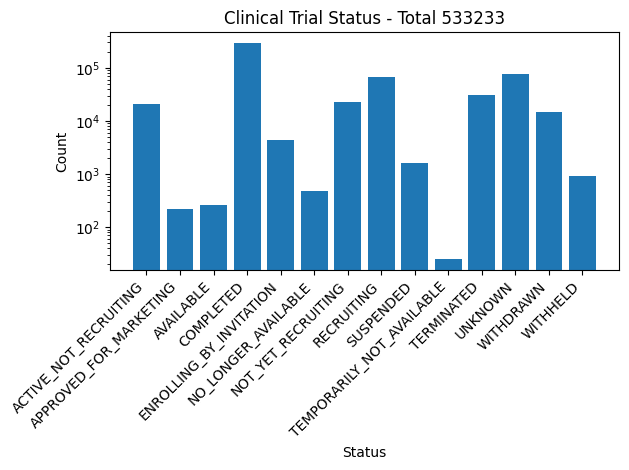

In [33]:
import matplotlib.pyplot as plt

plt.bar(records_count.keys(), records_count.values())
plt.xlabel('Status')
plt.ylabel('Count')
plt.yscale('log') 
plt.title(f'Clinical Trial Status - Total {sum(records_count.values())}')
# right-align x-ticks
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [38]:
records[0]

RealDictRow([('nct_id', 'NCT00000102'),
             ('official_title', None),
             ('brief_title',
              'Congenital Adrenal Hyperplasia: Calcium Channels as Therapeutic Targets'),
             ('updated_at', datetime.datetime(2025, 4, 6, 18, 1, 47, 260213)),
             ('overall_status', 'COMPLETED'),
             ('detailed_description',
              'This protocol is designed to assess both acute and chronic effects of the calcium channel antagonist, nifedipine, on the hypothalamic-pituitary-adrenal axis in patients with congenital adrenal hyperplasia. The multicenter trial is composed of two phases and will involve a double-blind, placebo-controlled parallel design. The goal of Phase I is to examine the ability of nifedipine vs. placebo to decrease adrenocorticotropic hormone (ACTH) levels, as well as to begin to assess the dose-dependency of nifedipine effects. The goal of Phase II is to evaluate the long-term effects of nifedipine; that is, can attenuation of 

In [19]:
records[0].get('overall_status')

'COMPLETED'

In [20]:
merged_texts = [merge_data_to_text(record) for record in records[:5]]

In [21]:
merged_texts[0]

'NCT ID: NCT00000102\nOfficial Title: \nBrief Title: Congenital Adrenal Hyperplasia: Calcium Channels as Therapeutic Targets\nUpdated At: 2025-04-06 18:01:47.260213\nDetailed Description: This protocol is designed to assess both acute and chronic effects of the calcium channel antagonist, nifedipine, on the hypothalamic-pituitary-adrenal axis in patients with congenital adrenal hyperplasia. The multicenter trial is composed of two phases and will involve a double-blind, placebo-controlled parallel design. The goal of Phase I is to examine the ability of nifedipine vs. placebo to decrease adrenocorticotropic hormone (ACTH) levels, as well as to begin to assess the dose-dependency of nifedipine effects. The goal of Phase II is to evaluate the long-term effects of nifedipine; that is, can attenuation of ACTH release by nifedipine permit a decrease in the dosage of glucocorticoid needed to suppress the HPA axis? Such a decrease would, in turn, reduce the deleterious effects of glucocortico

gene: hgnc
mycancergeno.gov

In [43]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [44]:

# AWS Lambda function details (replace with your own)
LAMBDA_REGION = 'ap-east-1'  # Your AWS region
LAMBDA_FUNCTION_NAME = 'clinmatch-dev-metamapParser'  # Your Lambda function name

def invoke_lambda(payload: Dict) -> Dict:
    """Invokes the AWS Lambda function with the given payload."""
    try:
        lambda_client = boto3.Session(aws_access_key_id=os.getenv('AWS_ACCESS_KEY_ID'), aws_secret_access_key=os.getenv('AWS_SECRET_ACCESS_KEY')).client('lambda', region_name=LAMBDA_REGION, )
        response = lambda_client.invoke(
            FunctionName=LAMBDA_FUNCTION_NAME,
            InvocationType='RequestResponse',
            Payload=json.dumps(payload)
        )
        response_payload = json.loads(response['Payload'].read().decode('utf-8'))
        logger.info("Successfully invoked Lambda function")
        return response_payload
    except Exception as e:
        logger.error(f"Error invoking Lambda function: {e}")
        raise


In [28]:
payload = {'text': merged_texts[0]}
result = invoke_lambda(payload)

2025-04-14 15:10:14,718 - INFO - Successfully invoked Lambda function


In [32]:
len(result['result'])

47

In [45]:
import pandas as pd

In [46]:
df_cancer_snomed_ct_tree = pd.read_json('./Data/SNOMED_CT_TREE.json')

In [35]:
from tqdm import tqdm

cui_df_cancer_snomed_ct_tree = [cui for cui in list(df_cancer_snomed_ct_tree['cui'])]
cui_df_cancer_snomed_ct_tree = set(cui_df_cancer_snomed_ct_tree)

for metamap_result in tqdm(result['result']): 
    metamap_result['onco_tag'] = metamap_result['cui'] in cui_df_cancer_snomed_ct_tree

100%|██████████| 47/47 [00:00<00:00, 880054.86it/s]


In [36]:
df = pd.DataFrame(result['result'])

In [37]:
df.head()

,cui,name,group,type,sources,matchedtext,start,length,onco_tag
0,C0001627,Congenital adrenal hyperplasia,disease,dsyn,"[LNC, MTH, CSP, ICD10CM, MSH, HPO, OMIM, CHV, ...",Congenital Adrenal Hyperplasia,50.0,30.0,False
1,C0006685,Calcium Channel,drug,bacs,"[MTH, CHV, CSP, MSH, NLMSubSyn, NCI, LCH_NW, AOD]",Calcium Channels,82.0,16.0,False
2,C0087111,Therapeutic procedure,drug,topp,"[MTH, LNC, CSP, MSH, NLMSubSyn, AOT, HL7V2.5, ...",Therapeutic,102.0,11.0,False
3,C0231491,Antagonist muscle action,disease,ortf,"[MTH, CHV, SNMI, SNM, UWDA, SNOMEDCT_US, FMA]",antagonist,273.0,10.0,False
4,C4721408,Substance with receptor antagonist mechanism o...,drug,phsu,"[MTH, NCI, SNOMEDCT_US]",antagonist,273.0,10.0,False


In [40]:
result

{'result': [{'cui': 'C0001627',
   'name': 'Congenital adrenal hyperplasia',
   'group': 'disease',
   'type': 'dsyn',
   'sources': ['LNC',
    'MTH',
    'CSP',
    'ICD10CM',
    'MSH',
    'HPO',
    'OMIM',
    'CHV',
    'SNMI',
    'SNM',
    'MEDLINEPLUS',
    'NCI',
    'SNOMEDCT_US',
    'DXP',
    'MTHICD9'],
   'matchedtext': 'Congenital Adrenal Hyperplasia',
   'start': 50,
   'length': 30,
   'onco_tag': False},
  {'cui': 'C0006685',
   'name': 'Calcium Channel',
   'group': 'drug',
   'type': 'bacs',
   'sources': ['MTH',
    'CHV',
    'CSP',
    'MSH',
    'NLMSubSyn',
    'NCI',
    'LCH_NW',
    'AOD'],
   'matchedtext': 'Calcium Channels',
   'start': 82,
   'length': 16,
   'onco_tag': False},
  {'cui': 'C0087111',
   'name': 'Therapeutic procedure',
   'group': 'drug',
   'type': 'topp',
   'sources': ['MTH',
    'LNC',
    'CSP',
    'MSH',
    'NLMSubSyn',
    'AOT',
    'HL7V2.5',
    'MTHMST',
    'HL7V3.0',
    'LCH',
    'CHV',
    'SNMI',
    'NCI',
    'LC

In [ ]:
import boto3
import logging
from botocore.exceptions import ClientError

DYNAMODB_TABLE_NAME = 'clinmatch-AACT-metamap'
AWS_REGION = 'ap-east-1'

dynamodb = boto3.Session(aws_access_key_id=os.getenv('AWS_ACCESS_KEY_ID'), aws_secret_access_key=os.getenv('AWS_SECRET_ACCESS_KEY')).resource('dynamodb', region_name=AWS_REGION)

def write_to_dynamodb(nct_id: str, updated_at: str, lambda_result: Dict):
    """Writes the Lambda result to DynamoDB along with nct_id and updated_at."""
    try:
        
        table = dynamodb.Table(DYNAMODB_TABLE_NAME)

        # Ensure updated_at is a string
        updated_at_str = str(updated_at)

        # Prepare the item to write
        item = {
            'nct_id': nct_id,
            'updated_at': updated_at_str,
            'lambda_result': lambda_result
        }

        # Write to DynamoDB
        table.put_item(Item=item)
        logger.info(f"Successfully wrote data for nct_id: {nct_id} to DynamoDB")
        
    except ClientError as e:
        logger.error(f"Error writing to DynamoDB: {e}")
        raise

In [223]:
dir = '/home/stevenhuang/Documents/clinmatch/clinmatch_AACT/failed_ids_phase1.txt'
with open(dir, 'r') as f:
    failed_ids = f.readlines()
failed_ids = [x.strip() for x in failed_ids]

In [224]:
len(failed_ids)

95

In [225]:
query = f"""
    SELECT 
        s.nct_id,
        s.official_title,
        s.brief_title,
        s.updated_at,
        s.overall_status,
        dd.description AS detailed_description,
        bs.description AS brief_summary,
        e.criteria,
        ARRAY_AGG(bc.downcase_mesh_term) AS mesh_terms
    FROM studies s
    LEFT JOIN detailed_descriptions dd ON s.nct_id = dd.nct_id
    LEFT JOIN brief_summaries bs ON s.nct_id = bs.nct_id
    LEFT JOIN eligibilities e ON s.nct_id = e.nct_id
    LEFT JOIN browse_conditions bc ON s.nct_id = bc.nct_id
    WHERE s.nct_id = 'NCT01552434'
    GROUP BY 
        s.nct_id, s.official_title, s.brief_title, s.updated_at, s.overall_status,
        dd.description, bs.description, e.criteria
    ORDER BY s.nct_id;
    """
try:
    cursor = conn.cursor(cursor_factory=RealDictCursor)
    cursor.execute(query)
    results = cursor.fetchall()
    cursor.close()
    logger.info(f"Fetched {len(results)} records from the database")
except Exception as e:
    logger.error(f"Error executing query: {e}")
    raise

2025-04-23 15:50:20,469 - INFO - Fetched 1 records from the database


In [226]:
len(merge_data_to_text(results[0]))

7839

In [220]:
text = merge_data_to_text(results[0]).replace('\'', ' ').replace("\\", "").replace('"', "")
payload_0 = {'text': text[:len(text)//2]}
payload_1 = {'text': text[len(text)//2:]}
payload_bytes = json.dumps(payload_0).encode('utf-8')

len(payload_0)

1

In [221]:
result = invoke_lambda(payload_0)

2025-04-23 15:36:32,086 - INFO - Successfully invoked Lambda function


In [222]:
result

{'result': [{'cui': 'C0021102',
   'name': 'Implants',
   'group': 'biomarker',
   'type': 'medd',
   'sources': ['MTH',
    'CHV',
    'LNC',
    'SNMI',
    'SNM',
    'NLMSubSyn',
    'NCI',
    'SNOMEDCT_US'],
   'matchedtext': 'Implantable',
   'start': 54,
   'length': 11},
  {'cui': 'C5206874',
   'name': 'Drug Delivery Microdevice',
   'group': 'biomarker',
   'type': 'medd',
   'sources': ['NCI'],
   'matchedtext': 'Microdevice',
   'start': 66,
   'length': 11},
  {'cui': 'C0205065',
   'name': 'Ovarian',
   'group': 'organ',
   'type': 'bpoc',
   'sources': ['CHV', 'SNMI', 'NCI'],
   'matchedtext': 'Ovarian',
   'start': 119,
   'length': 7},
  {'cui': 'C4266534',
   'name': 'Pelvis>Fallopian tube',
   'group': 'organ',
   'type': 'bpoc',
   'sources': ['LNC', 'MTH'],
   'matchedtext': 'Fallopian Tube',
   'start': 128,
   'length': 14},
  {'cui': 'C0015560',
   'name': 'Fallopian Tubes',
   'group': 'organ',
   'type': 'bpoc',
   'sources': ['MTH',
    'LNC',
    'CSP',
   

In [206]:
text

'NCT ID: NCT01552434\nOfficial Title: A Phase I Trial of Bevacizumab, Temsirolimus Alone and in Combination with Valproic Acid, or Cetuximab in Patients with Advanced Malignancy and Other Indications\nBrief Title: Bevacizumab and Temsirolimus Alone or in Combination with Valproic Acid or Cetuximab in Treating Patients with Advanced or Metastatic Malignancy or Other Benign Disease\nUpdated At: 2025-04-07 08:01:30.738367\nDetailed Description: PRIMARY OBJECTIVES:\n\nI. To determine the maximum tolerated doses (MTDs) and dose-limiting toxicities (DLTs) of treatment with bevacizumab and temsirolimus in combination and plus valproic acid or cetuximab.\n\nSECONDARY OBJECTIVES:\n\nI. Preliminary descriptive assessment of anti-tumor efficacy of each combination.\n\nII. Preliminary assessment of the pharmacokinetic, pharmacodynamic markers of target inhibition and correlates of response (optional).\n\nOUTLINE: This is a dose-escalation study of bevacizumab and temsirolimus. Patients are assigne